## Challenge

If you've completed this project and you're looking for a challenge, try to implement the following using the `pandas`, `scipy`, and `seaborn` packages.

* Import both `data/control.txt' and 'data/treatment.txt' files as dataframes.
* Calculate descriptive statistics on both dataframes.
* Plot the dataframes using a seaborn method of your choice.
* Perform a t-test on both dataframes using the `ttest_ind` method from scipy.

The following documentation will be helpful in accomplishing these tasks:
* https://pandas.pydata.org/docs/user_guide/10min.html
* https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

=== Control Group Stats ===
       viewing_time
count    500.000000
mean      12.450520
std        3.261753
min        3.690000
25%       10.345000
50%       12.640000
75%       14.672500
max       21.210000

=== Treatment Group Stats ===
       viewing_time
count    500.000000
mean      16.797080
std        2.085981
min       10.330000
25%       15.347500
50%       16.835000
75%       18.215000
max       22.850000


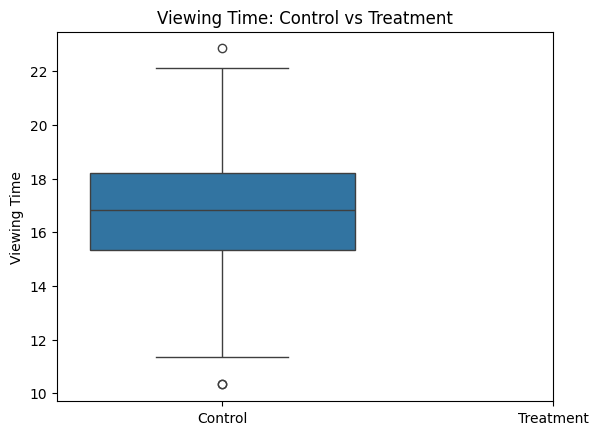


T-statistic: -25.1030
P-value: 0.0000
Result: Statistically significant difference (reject null hypothesis)


In [15]:
# TODO: implement your code here...
...# Load both files as dataframes
control_df = pd.read_csv('data/control.txt', header=None, names=['viewing_time'])
treatment_df = pd.read_csv('data/treatment.txt', header=None, names=['viewing_time'])

control_df['viewing_time'] = pd.to_numeric(control_df['viewing_time'], errors='coerce')
treatment_df['viewing_time'] = pd.to_numeric(treatment_df['viewing_time'], errors='coerce')

control_df = control_df.dropna()
treatment_df = treatment_df.dropna()

# Descriptive statistics
print("=== Control Group Stats ===")
print(control_df.describe())

print("\n=== Treatment Group Stats ===")
print(treatment_df.describe())

# Plot using seaborn
sns.boxplot(data=[control_df['viewing_time'], treatment_df['viewing_time']])
plt.xticks([0, 1], ['Control', 'Treatment'])
plt.title('Viewing Time: Control vs Treatment')
plt.ylabel('Viewing Time')
plt.show()

# T-test
t_stat, p_value = stats.ttest_ind(control_df['viewing_time'], treatment_df['viewing_time'])
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (reject null hypothesis)")
else:
    print("Result: No statistically significant difference (fail to reject null hypothesis)")